In [ ]:
import nltk
import urllib.request

nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.probability import FreqDist
from nltk.corpus import stopwords

url = "https://www.gutenberg.org/files/84/84-0.txt"

with urllib.request.urlopen(url) as response:
    text = response.read().decode("utf-8")

tokens = nltk.word_tokenize(text.lower())

stop_words = set(stopwords.words('english'))

clean_tokens = [
    token for token in tokens
    if token.isalpha()
    and token not in stop_words
]

frequency = FreqDist(clean_tokens)

print("Top 100 most frequent words:\n")
for word, count in frequency.most_common(100):
    print(f"  {word:<20} {count}")

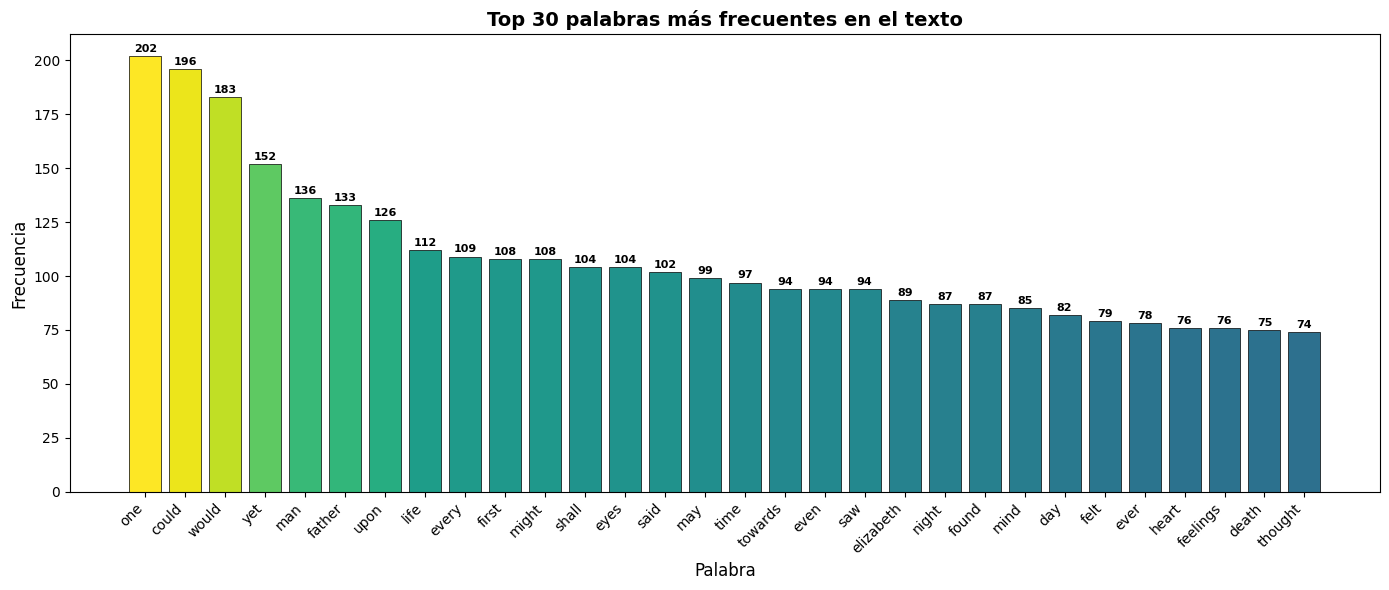

In [ ]:
import matplotlib.pyplot as plt

top_n = 30
most_common = frequency.most_common(top_n)
words = [word for word, count in most_common]
counts = [count for word, count in most_common]

plt.figure(figsize=(14, 6))
bars = plt.bar(words, counts, color=plt.cm.viridis([c / max(counts) for c in counts]), edgecolor="black", linewidth=0.5)
plt.xlabel("Palabra", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.title(f"Top {top_n} palabras más frecuentes en el texto", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.tight_layout()

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(count),
            ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.show()